# Detail-Auswertung

## Imports and constants

In [1]:
# Imports / global contants

# csv Dateien sind im Verzeichnis ../data zu finden

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib import figure
import math
import numpy as np
import seaborn as sns
from scipy.misc import electrocardiogram
from scipy.signal import find_peaks
import gc
import pylab

from pandas.plotting import parallel_coordinates

%matplotlib inline

timeFormat = "%Y-%m-%dT%H:%M:%S.%fZ"

export = "../export/"
export_img = "../export/img/"
export_interactions = "../export/interaction/"

path = "../data/"

---
## Function: Extract Interactions from cleaned data

* removes all logs before the start of the trial and after it has ended with completed / failed / terminated state
* saved to `export/cleanedStudy_interactionOnly.csv`
* stored in `df_cleaned`


---

In [2]:
df_cleaned = pd.read_csv(rf'{export}cleanedStudy.csv', sep=";")

# retrieve labels for results
states = df_cleaned[
    ((df_cleaned["posX"] == " COMPLETED") | 
    (df_cleaned["posX"] == " FAILED") | 
    (df_cleaned["posX"] == " TERMINATED") | 
    (df_cleaned["posX"] == " START"))
  ]

# insert labels
df_cleaned["Result"] = states["posX"]

# fill (bottom-up)
df_cleaned["Result"].fillna(method='bfill', inplace=True)

# drop na (end)
df_cleaned = df_cleaned.dropna(subset=["Result"])

# drop start (between trials)
df_cleaned = df_cleaned.drop(df_cleaned[(df_cleaned["Result"] == " START") & (df_cleaned["posX"] != " START")].index)

df_cleaned["Block"] = (df_cleaned["TaskNo"] / 18).apply(np.ceil).astype(int)
df_cleaned["TaskNo"] = (df_cleaned["TaskNo"] - ((df_cleaned["Block"] - 1) * 18)).astype(int)
df_cleaned["TrialIdx"] = df_cleaned["TrialIdx"].astype(int)   
df_cleaned["TargetLayers"] = df_cleaned["TargetLayers"].str.split(",")
df_cleaned["Target"] = df_cleaned.apply(lambda item: item["TargetLayers"][item["TrialIdx"]], axis = 1).astype(int)
df_cleaned["Target_Relative"] = df_cleaned["Target"].astype(float) / df_cleaned["LayerCount"].astype(float)

df_cleaned.reset_index(inplace=True)

df_cleaned.rename(columns={ df_cleaned.columns[0]:"SampleIdx_global", df_cleaned.columns[1]:"SampleIdx_Proband", "TrialIdx":"Trial", "LayerCount":"NumLayers", "TaskNo":"Task" }, inplace=True)

display(df_cleaned)

df_cleaned.to_csv(rf'{export}cleanedStudy_interactionOnly.csv', sep= ";")



,SampleIdx_global,SampleIdx_Proband,DateTime,State,mappingMethod,Task,TargetLayers,NumLayers,Trial,posX,...,posZ,TimeStamp,iteractionType,currentLayer,Proband,shifted,Result,Block,Target,Target_Relative
0,135,135,2021-05-10T12:13:56.584Z,VIEW,direct,1,"[4, 5, 3, 1, 2]",6,0,START,...,NaN,NaN,NaN,NaN,1,1.0,START,1,4,0.666667
1,136,136,2021-05-10T12:13:56.602Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,2,1,1.0,COMPLETED,1,4,0.666667
2,137,137,2021-05-10T12:13:56.633Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,2,1,1.0,COMPLETED,1,4,0.666667
3,138,138,2021-05-10T12:13:56.676Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,-,1,1.0,COMPLETED,1,4,0.666667
4,139,139,2021-05-10T12:13:56.697Z,INTERACTION,direct,1,"[4, 5, 3, 1, 2]",6,0,-,...,-,-,-,-,1,1.0,COMPLETED,1,4,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535230,2360983,90204,2021-06-30T12:37:15.245Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.252979726,...,-0.9999999,637606606352421800,1,6,24,54.0,FAILED,3,1,0.166667
1535231,2360984,90205,2021-06-30T12:37:15.291Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.231738284,...,-0.9999999,637606606352861800,1,6,24,54.0,FAILED,3,1,0.166667
1535232,2360985,90206,2021-06-30T12:37:15.323Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.231738284,...,-0.9999999,637606606353161900,1,6,24,54.0,FAILED,3,1,0.166667
1535233,2360986,90207,2021-06-30T12:37:15.361Z,INTERACTION,widening,18,"[4, 5, 2, 3, 1]",6,4,0.240411818,...,-0.9999999,637606606353551700,1,6,24,54.0,FAILED,3,1,0.166667


---
## Function: extract layer borders

`getLayerBorders(layers, mapping)`

---

In [3]:
def getLayerBorders(layers, mapping):
    layerdata = pd.read_csv(rf'{path}meta/depthlayers.csv', sep=";")

    layer = layerdata[(layerdata.iloc[:,0] == layers) & (layerdata.iloc[:, 1] == mapping)]

    return np.array(layer.iloc[:,3].str.split("|").iloc[0], float)

---
## Function: Draw Graph for a single Trial

`drawSingleInteractionGraph(proband, block, task, trial, show=False)`

---

In [4]:
df_cleaned = pd.read_csv(rf'{export}cleanedStudy_interactionOnly.csv', sep=";")

# proband = 24
# task = 18
# block = 3
# trial = 3

def drawSingleInteractionGraph(proband, block, task, trial, show=False):

    exp_data = df_cleaned[(df_cleaned["Proband"] == proband) & (df_cleaned["Task"] == task) & (df_cleaned["Block"] == block) & (df_cleaned["Trial"] == trial)].reset_index(drop=True)

    z_data = exp_data["posZ"].replace("-", 0).astype(float)

    target = exp_data["Target"][0]
    num_layers = exp_data["NumLayers"][0]
    mapping = exp_data["mappingMethod"][0]

    borders = getLayerBorders(num_layers, mapping)

    miny = [-borders[target+1]]*len(z_data)
    maxy = [-borders[target]]*len(z_data)

    hold = exp_data[exp_data["posX"] == " HOLD"].index

    ex_max, _ = find_peaks(z_data, prominence=0.05)
    ex_min, _ = find_peaks(-z_data, prominence=0.05)

    peaks = np.concatenate([ex_max,ex_min])

    fig,ax = plt.subplots(1, 1, tight_layout=True, figsize=(25,8), clear=True)

    ax.plot(exp_data.index, z_data, label='Depth')
    ax.plot(peaks, z_data[peaks], "o")

    plt.vlines(x= hold, ymin=-1, ymax=0, linestyles="--")

    ax.plot(miny, linestyle=":")
    ax.plot(maxy, linestyle=":")
    
    plt.suptitle(f'Proband {proband}: Block {block} | Task {task} | Trial {trial}',fontsize=20, y=1)
    plt.title(f'{num_layers} Layers ({mapping}) | Target: {target}',fontsize=16)

    plt.savefig(rf'{export_interactions}single/Interaction_p{proband}_{block}_{task}_{trial}.jpg')
    plt.savefig(rf'{export_interactions}single/Interaction_p{proband}_{block}_{task}_{trial}.svg')

    if show:
        plt.show()
    else:   
        plt.close(fig)          

---
## Function: Draw Graph for specific configuration

`drawInteractionGraph(num_layers, target, mapping, show=False)`

---

In [10]:
def drawInteractionGraph(num_layers, target, mapping, show=False):

   exp_data_complete = df_cleaned[(df_cleaned["mappingMethod"] == mapping) & (df_cleaned["Target"] == target) & (df_cleaned["NumLayers"] == num_layers)].reset_index(drop=True).groupby(["Proband", "Task", "Block", "Trial"])

   borders = getLayerBorders(num_layers, mapping)

   fig,ax = plt.subplots(1, 1, tight_layout=True, figsize=(25,8), clear=True)

   z_data = pd.DataFrame()
   peaks = pd.DataFrame()
   hold = []

   for name, group in exp_data_complete:

      norm = group.reset_index(drop=True)

      newData = norm["posZ"].replace("-", 0).astype(float)
      z_data = pd.concat([z_data, newData], axis=1, ignore_index=True)

      ax.plot(newData.index, newData, label=name)

      ex_max, _ = find_peaks(newData, prominence=0.05)
      ex_min, _ = find_peaks(-newData, prominence=0.05)

      newPeaks = np.concatenate([ex_max,ex_min])
      peaks = pd.concat([peaks, pd.DataFrame(newPeaks)], axis=1, ignore_index=True)
      
      ax.plot(newPeaks, newData[newPeaks], "o")

      newHold = np.array(norm[norm["posX"] == " HOLD"].index)

      hold = np.concatenate([hold, newHold])

   plt.vlines(x= hold, ymin=-1, ymax=0, linestyles="--")

   miny = [-borders[target+1]]*len(z_data)
   maxy = [-borders[target]]*len(z_data)

   ax.plot(miny, linestyle=":")
   ax.plot(maxy, linestyle=":")

   plt.suptitle(f'{num_layers} Layers ({mapping}) | Target: {target}',fontsize=20, y=1)

   plt.savefig(rf'{export_interactions}allInteractions_{target}-{num_layers}_{mapping}.jpg')
   plt.savefig(rf'{export_interactions}allInteractions_{target}-{num_layers}_{mapping}.svg')
     
   if show:
      plt.show()
   else:
      plt.close(fig)

---
## Draw __ALL__ interaction graphs per configuration (Layers/Target/MappingMethod)

generate and save images as .jpg and .csv (png not working: axes are not correctly exported)

---

In [ ]:
# num layers
all_layers = [6,9,12,15,18,21]

# mapping
mappings = [" direct", " densening", " widening"]

plt.ioff()
plt.close('all')

for num in all_layers:
    all_targets = np.array(df_cleaned[df_cleaned["NumLayers"] == num]["Target"].drop_duplicates().sort_values())
    gc.collect()
    print(f'plotting config for {num} layers')
    for target in all_targets:
        for map in mappings:
            drawInteractionGraph(num, target, map)

plt.ion()

---
## Draw __ALL__ Single Interaction Graphs

generate and save images as .jpg and .csv (png not working: axes are not correctly exported)

---

In [ ]:
all_probands = np.array(df_cleaned["Proband"].drop_duplicates().sort_values())
all_blocks = np.array(df_cleaned["Block"].drop_duplicates().sort_values())
all_tasks = np.array(df_cleaned["Task"].drop_duplicates().sort_values())
all_trials = np.array(df_cleaned["Trial"].drop_duplicates().sort_values())

print(f'Starting to plot all single graphs for {len(all_probands)} Probands')
plt.ioff()
plt.close('all')

for p in all_probands:
    gc.collect()    
    for b in all_blocks:       
        for t in all_tasks:
            for tr in all_trials:
                drawSingleInteractionGraph(p,b,t,tr)
    print(f'Finished Proband {p}')  

plt.ion()

--- 
## Function: Statistics for peaks

| NumLayers | MappingMethod | TargetLayer | Peaks_Z           | Peaks_total | Peaks_lower  | Peaks_inside | Peaks_deeper| Peaks_before_hold | Peaks_after_hold | Result    |
| --------- | ------------- | ----------- | ----------------- | ----------- | ------------ | ------------ | ----------- | ------------------| ---------------- | --------- | 
| 21        | direct        | 6           | [-0.1, -0.5, ...] | 6           | 3            | 1            | 2           | 6                 | 0                | COMPLETED |

---

In [49]:
df_cleaned = pd.read_csv(rf'{export}cleanedStudy_interactionOnly.csv', sep=";")

def extractAllPeaks(num_layers, mapping, target):
   exp_data_complete = df_cleaned[(df_cleaned["mappingMethod"] == mapping) & (df_cleaned["Target"] == target) & (df_cleaned["NumLayers"] == num_layers)].reset_index(drop=True).groupby(["Proband", "Task", "Block", "Trial"])

   borders = getLayerBorders(num_layers, mapping)

   complete = pd.DataFrame()

   for name, group in exp_data_complete:
      
      result = pd.DataFrame()      

      norm = group.reset_index(drop=True)

      z_data = np.array(norm["posZ"].replace("-", 0).astype(float), float)  

      ex_max, _ = find_peaks(z_data, prominence=0.05)
      ex_min, _ = find_peaks(-z_data, prominence=0.05)
      
      peaks = []
      # if len(ex_min) + len(ex_max) > 0:
      peaks = np.concatenate([ex_max,ex_min])

      pos = norm[norm["posX"] == " HOLD"]
      
      if len(pos) == 1:
         hold = np.array(pos.index)

      else: #hold.isnull():
         hold = np.array(norm.index[-1])

      peaks_z = pd.DataFrame(pd.DataFrame(peaks).apply(lambda item: norm.iloc[item.index]["posZ"])[0].replace(to_replace='-', value='0').astype(float).fillna(0))
           
      result["Peaks_Z"] = [peaks_z[0].values]
      result["Peaks_Total"] = len(peaks)

      result["Result"] = norm["Result"][1]

      result["HOLD_idx"] = [hold]

      before = peaks[peaks >= hold]
      after = peaks[peaks < hold]

      result["Peaks_AfterHold"] = len(before)
      result["Peaks_AfterHold_Values"] = [before]
      result["Peaks_BeforeHold"] = len(after)
      result["Peaks_BeforeHold_Values"] = [after]

      lower = peaks_z[peaks_z[0] > -borders[target]]
      deeper = peaks_z[peaks_z[0] < -borders[target+1]]

      result["Peaks_lower"] = len(lower)
      result["Peaks_lower_Values"] = [lower[0].values]
      result["Peaks_deeper"] = len(deeper)
      result["Peaks_deeper_Values"] = [deeper[0].values]

      result["Peaks_between"] = result["Peaks_Total"] - (result["Peaks_lower"] + result["Peaks_deeper"])

      result["Peaks_Z"] = result["Peaks_Z"]
      
      complete = pd.concat([complete, result])
   

   complete["NumLayers"] = num_layers
   complete["MappingMethod"] = mapping
   complete["TargetLayer"] = target
   complete["TargetDepth"] = -0.5 * (borders[target] + borders[target+1])

   return complete
   
# test
peaks_df = extractAllPeaks(6, " densening", 1)
display(peaks_df)

,Peaks_Z,Peaks_Total,Result,HOLD_idx,Peaks_AfterHold,Peaks_AfterHold_Values,Peaks_BeforeHold,Peaks_BeforeHold_Values,Peaks_lower,Peaks_lower_Values,Peaks_deeper,Peaks_deeper_Values,Peaks_between,NumLayers,MappingMethod,TargetLayer,TargetDepth
0,"[0.0, -0.228947267]",2,TERMINATED,[114],0,[],2,"[14, 51]",1,[0.0],0,[],1,6,densening,1,-0.31605
0,"[0.0, -0.509210467]",2,COMPLETED,[101],0,[],2,"[12, 47]",1,[0.0],1,[-0.509210467],0,6,densening,1,-0.31605
0,"[0.0, -0.552631557, -0.378947318]",3,TERMINATED,[70],0,[],3,"[13, 46, 50]",1,[0.0],1,[-0.552631557],1,6,densening,1,-0.31605
0,[0.0],1,TERMINATED,[70],0,[],1,[18],1,[0.0],0,[],0,6,densening,1,-0.31605
0,"[0.0, -0.5644736]",2,COMPLETED,[96],0,[],2,"[15, 46]",1,[0.0],1,[-0.5644736],0,6,densening,1,-0.31605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,[0.0],1,COMPLETED,[102],0,[],1,[22],1,[0.0],0,[],0,6,densening,1,-0.31605
0,"[0.0, -0.7499999]",2,COMPLETED,[94],0,[],2,"[19, 54]",1,[0.0],1,[-0.7499999],0,6,densening,1,-0.31605
0,"[0.0, -0.256578863, -0.307894677]",3,COMPLETED,[99],0,[],3,"[27, 10, 57]",1,[0.0],0,[],2,6,densening,1,-0.31605
0,"[0.0, -0.0828946456]",2,COMPLETED,[67],0,[],2,"[4, 18]",2,"[0.0, -0.0828946456]",0,[],0,6,densening,1,-0.31605


---

## Function: save peaks to file

* correct serialization of cells containing numpy arrays using `np.array2string`
* saved to `export/all_peaks.csv'`

---

In [50]:
def savePeaks(result_all):
    # need to extra format floating point lists as pandas serialization does not like them
    result_all["Peaks_Z"] = result_all["Peaks_Z"].apply(lambda item: np.array2string(item, separator="|"))
    result_all["Peaks_lower_Values"] = result_all["Peaks_lower_Values"].apply(lambda item: np.array2string(item, separator="|"))
    result_all["Peaks_deeper_Values"] = result_all["Peaks_deeper_Values"].apply(lambda item: np.array2string(item, separator="|"))

    result_all.to_csv(rf'{export}all_peaks.csv', sep= ";")

---

## Function: load peaks from file

* correct deserialization of cells containing numpy arrays using `np.fromstring`
* load from `export/all_peaks.csv'`

---

In [15]:
def loadPeaks():
    result = pd.read_csv(rf'{export}all_peaks.csv', sep= ";")

    # when importing: convert back to pandas arrays
    result["Peaks_Z"] = result["Peaks_Z"].apply(lambda item: np.fromstring(item.replace('[','').replace(']',''), dtype=float, sep="|"))
    result["Peaks_lower_Values"] = result["Peaks_lower_Values"].apply(lambda item: np.fromstring(item.replace('[','').replace(']',''), dtype=float, sep="|"))
    result["Peaks_deeper_Values"] = result["Peaks_deeper_Values"].apply(lambda item: np.fromstring(item.replace('[','').replace(']',''), dtype=float, sep="|")) 

    return result

---

## Iterate over all configurations (NumLayers / MappingMethod / Targets) to extract all peaks

saved to `export\all_peaks.csv`

---

In [51]:
all_layers = np.array(df_cleaned["NumLayers"].drop_duplicates().sort_values())
all_mappings = np.array(df_cleaned["mappingMethod"].drop_duplicates().sort_values())

result_all = pd.DataFrame()

for l in all_layers:  
    for m in all_mappings:
        all_targets = np.array(df_cleaned[(df_cleaned["NumLayers"] == l) & (df_cleaned["mappingMethod"] == m)]["Target"].drop_duplicates().sort_values())
        print(f'{l} layers [{m}] - targets: {all_targets}')
        for t in all_targets:
            # print(f'{l}, {m}, {t}')
            p = extractAllPeaks(l, m, t)            
            result_all = pd.concat([result_all, p])

savePeaks(result_all)

6 layers [ densening] - targets: [1 2 3 4 5]
6 layers [ direct] - targets: [1 2 3 4 5]
6 layers [ widening] - targets: [1 2 3 4 5]
9 layers [ densening] - targets: [1 2 5 7 8]
9 layers [ direct] - targets: [1 2 5 7 8]
9 layers [ widening] - targets: [1 2 5 7 8]
12 layers [ densening] - targets: [ 1  3  6  9 11]
12 layers [ direct] - targets: [ 1  3  6  9 11]
12 layers [ widening] - targets: [ 1  3  6  9 11]
15 layers [ densening] - targets: [ 1  4  8 11 14]
15 layers [ direct] - targets: [ 1  4  8 11 14]
15 layers [ widening] - targets: [ 1  4  8 11 14]
18 layers [ densening] - targets: [ 1  5  9 14 17]
18 layers [ direct] - targets: [ 1  5  9 14 17]
18 layers [ widening] - targets: [ 1  5  9 14 17]
21 layers [ densening] - targets: [ 1  5 11 16 20]
21 layers [ direct] - targets: [ 1  5 11 16 20]
21 layers [ widening] - targets: [ 1  5 11 16 20]


--- 

## Draw Graph for peaks statistics

---

NumLayers Peaks_Total                 Peaks_lower                  \
                    sum count      mean         sum count      mean   
0         6        1891  1035  1.827053        1455  1035  1.405797   
1         9        2290  1035  2.212560        1729  1035  1.670531   
2        12        2822  1035  2.726570        2192  1035  2.117874   
3        15        3397  1035  3.282126        2634  1035  2.544928   
4        18        3714  1035  3.588406        2921  1035  2.822222   
5        21        4031  1035  3.894686        3114  1035  3.008696   

  Peaks_deeper                 Peaks_between                  
           sum count      mean           sum count      mean  
0          281  1035  0.271498           155  1035  0.149758  
1          451  1035  0.435749           110  1035  0.106280  
2          517  1035  0.499517           113  1035  0.109179  
3          654  1035  0.631884           109  1035  0.105314  
4          668  1035  0.645411           125  1035  0.120773  
5          805  1035  0.777778           112  1035  0.108213

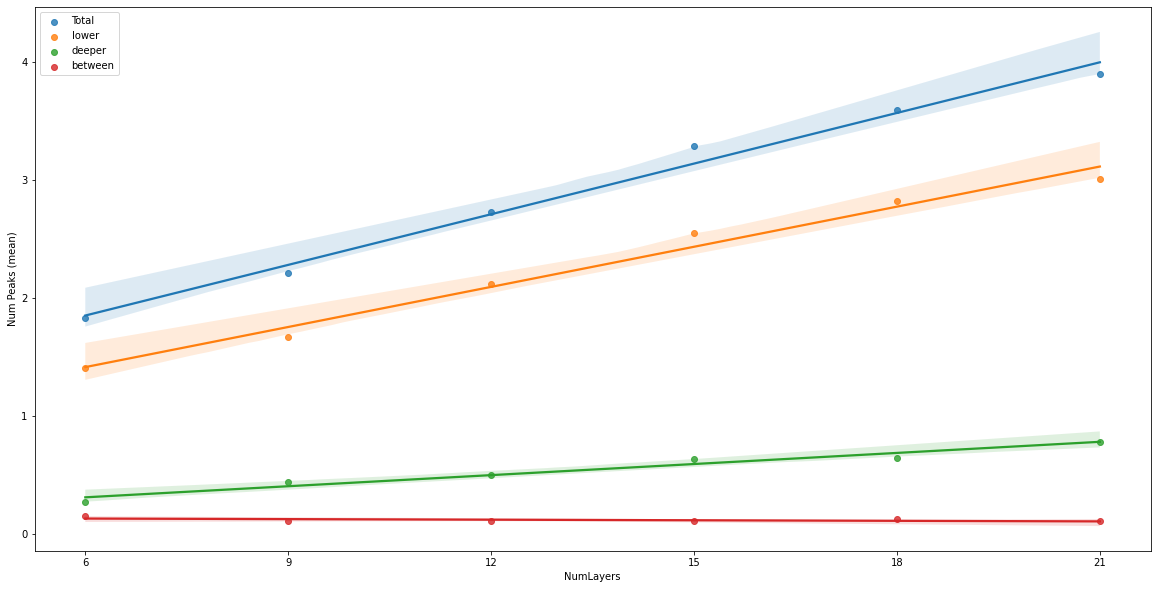

MappingMethod NumLayers Peaks_Total                 Peaks_lower        \
                                   sum count      mean         sum count   
0      densening         6         656   345  1.901449         564   345   
1      densening         9         783   345  2.269565         652   345   
2      densening        12         905   345  2.623188         740   345   
3      densening        15        1135   345  3.289855         938   345   
4      densening        18        1336   345  3.872464        1132   345   
5      densening        21        1358   345  3.936232        1137   345   
6         direct         6         613   345  1.776812         451   345   
7         direct         9         758   345  2.197101         559   345   
8         direct        12         983   345  2.849275         765   345   
9         direct        15        1142   345  3.310145         861   345   
10        direct        18        1207   345  3.498551         949   345   
11        direct        21        1311   345  3.800000        1008   345   
12      widening         6         622   345  1.802899         440   345   
13      widening         9         749   345  2.171014         518   345   
14      widening        12         934   345  2.707246         687   345   
15      widening        15        1120   345  3.246377         835   345   
16      widening        18        1171   345  3.394203         840   345   
17      widening        21        1362   345  3.947826         969   345   

             Peaks_deeper                 Peaks_between                  
        mean          sum count      mean           sum count      mean  
0   1.634783           37   345  0.107246            55   345  0.159420  
1   1.889855           88   345  0.255072            43   345  0.124638  
2   2.144928          132   345  0.382609            33   345  0.095652  
3   2.718841          169   345  0.489855            28   345  0.081159  
4   3.281159          163   345  0.472464            41   345  0.118841  
5   3.295652          171   345  0.495652            50   345  0.144928  
6   1.307246          102   345  0.295652            60   345  0.173913  
7   1.620290          160   345  0.463768            39   345  0.113043  
8   2.217391          184   345  0.533333            34   345  0.098551  
9   2.495652          235   345  0.681159            46   345  0.133333  
10  2.750725          212   345  0.614493            46   345  0.133333  
11  2.921739          273   345  0.791304            30   345  0.086957  
12  1.275362          142   345  0.411594            40   345  0.115942  
13  1.501449          203   345  0.588406            28   345  0.081159  
14  1.991304          201   345  0.582609            46   345  0.133333  
15  2.420290          250   345  0.724638            35   345  0.101449  
16  2.434783          293   345  0.849275            38   345  0.110145  
17  2.808696          361   345  1.046377            32   345  0.092754

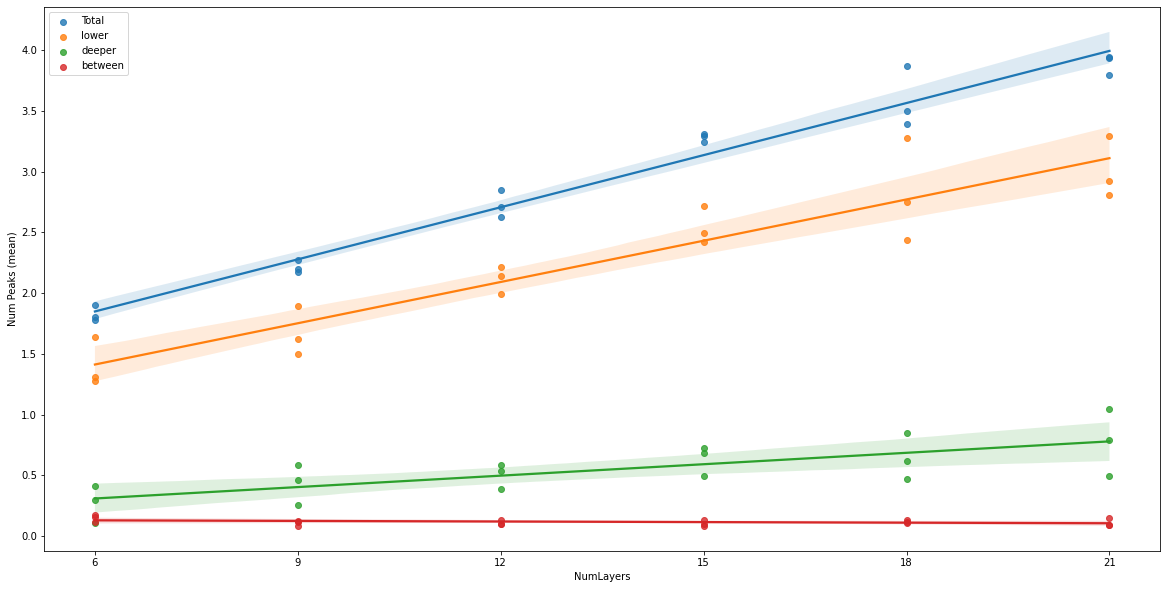

TargetLayer Peaks_Total                 Peaks_lower                  \
                       sum count      mean         sum count      mean   
0            1        4062  1242  3.270531        2100  1242  1.690821   
1            2         922   414  2.227053         579   414  1.398551   
2            3        1004   414  2.425121         735   414  1.775362   
3            4        1080   414  2.608696         782   414  1.888889   
4            5        2577   828  3.112319        1873   828  2.262077   
5            6         617   207  2.980676         525   207  2.536232   
6            7         357   207  1.724638         354   207  1.710145   
7            8        1060   414  2.560386         970   414  2.342995   
8            9        1285   414  3.103865        1153   414  2.785024   
9           11        1930   621  3.107890        1762   621  2.837359   
10          14        1202   414  2.903382        1186   414  2.864734   
11          16         756   207  3.652174         743   207  3.589372   
12          17         655   207  3.164251         647   207  3.125604   
13          20         638   207  3.082126         636   207  3.072464   

   Peaks_deeper                 Peaks_between                  
            sum count      mean           sum count      mean  
0          1754  1242  1.412238           208  1242  0.167472  
1           256   414  0.618357            87   414  0.210145  
2           194   414  0.468599            75   414  0.181159  
3           250   414  0.603865            48   414  0.115942  
4           570   828  0.688406           134   828  0.161836  
5            54   207  0.260870            38   207  0.183575  
6             0   207  0.000000             3   207  0.014493  
7            61   414  0.147343            29   414  0.070048  
8            90   414  0.217391            42   414  0.101449  
9           120   621  0.193237            48   621  0.077295  
10           11   414  0.026570             5   414  0.012077  
11            6   207  0.028986             7   207  0.033816  
12            8   207  0.038647             0   207  0.000000  
13            2   207  0.009662             0   207  0.000000

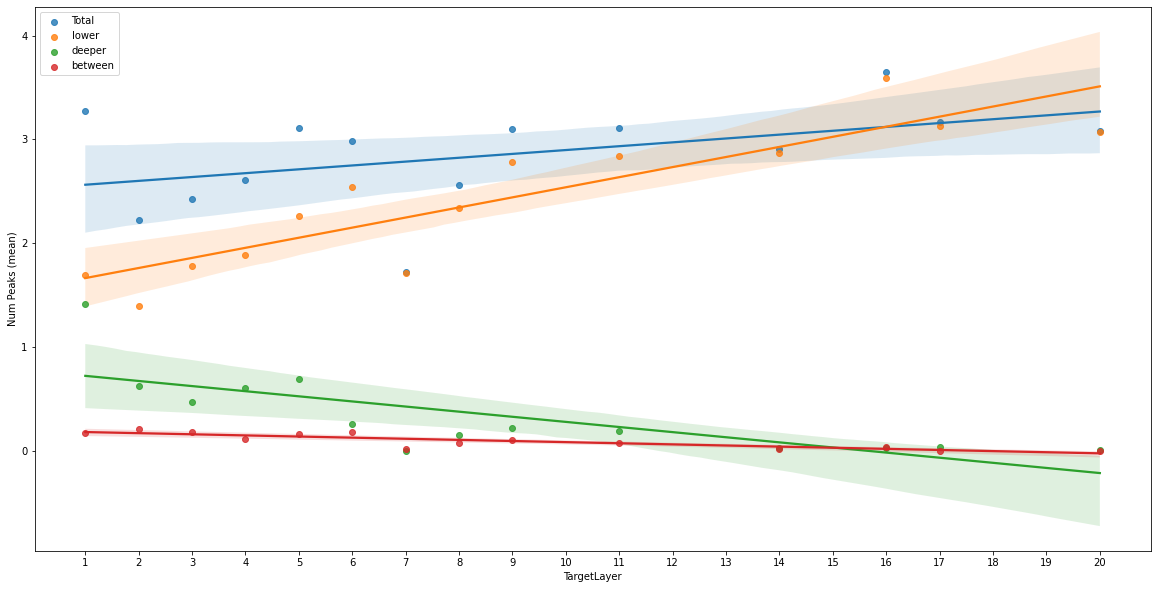

TargetDepth Peaks_Total                 Peaks_lower                  \
                       sum count      mean         sum count      mean   
0     -0.96995         265    69  3.840580         265    69  3.840580   
1     -0.96485         249    69  3.608696         249    69  3.608696   
2     -0.95770         186    69  2.695652         186    69  2.695652   
3     -0.95240         185    69  2.681159         185    69  2.681159   
4     -0.94690         167    69  2.420290         167    69  2.420290   
..         ...         ...   ...       ...         ...   ...       ...   
82    -0.02930         192    69  2.782609         104    69  1.507246   
83    -0.01820         187    69  2.710145          99    69  1.434783   
84    -0.01255         292    69  4.231884         196    69  2.840580   
85    -0.00925         275    69  3.985507         155    69  2.246377   
86    -0.00715         326    69  4.724638         177    69  2.565217   

   Peaks_deeper                 Peaks_between                  
            sum count      mean           sum count      mean  
0             0    69  0.000000             0    69  0.000000  
1             0    69  0.000000             0    69  0.000000  
2             0    69  0.000000             0    69  0.000000  
3             0    69  0.000000             0    69  0.000000  
4             0    69  0.000000             0    69  0.000000  
..          ...   ...       ...           ...   ...       ...  
82           78    69  1.130435            10    69  0.144928  
83           82    69  1.188406             6    69  0.086957  
84           94    69  1.362319             2    69  0.028986  
85          110    69  1.594203            10    69  0.144928  
86          145    69  2.101449             4    69  0.057971  

[87 rows x 13 columns]

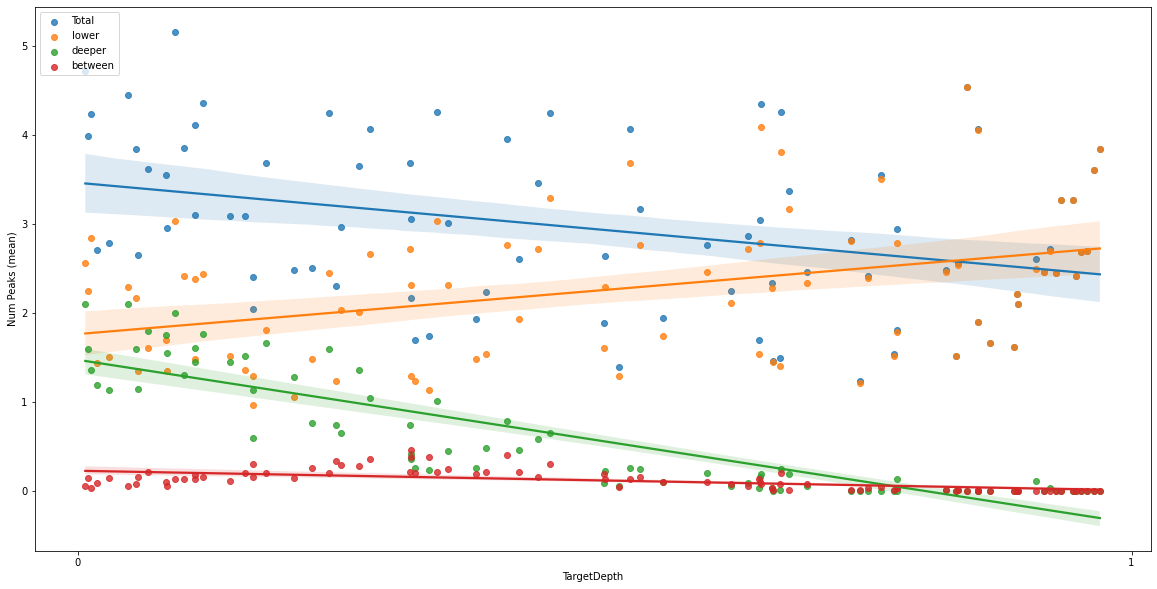

In [54]:
peaks = loadPeaks()

# group by layers only
grouped_layers = peaks.groupby(["NumLayers"])[["Peaks_Total", "Peaks_lower", "Peaks_deeper", "Peaks_between"]].agg(["sum", "count", "mean"]).reset_index()

display(grouped_layers)

fig_layers = plt.figure(figsize=(20,10))

ax_layers = sns.regplot(x=grouped_layers["NumLayers"], y=grouped_layers["Peaks_Total"]["mean"], label='Total')
ax_layers = sns.regplot(x=grouped_layers["NumLayers"], y=grouped_layers["Peaks_lower"]["mean"], label='lower')
ax_layers = sns.regplot(x=grouped_layers["NumLayers"], y=grouped_layers["Peaks_deeper"]["mean"], label='deeper')
ax_layers = sns.regplot(x=grouped_layers["NumLayers"], y=grouped_layers["Peaks_between"]["mean"], label='between')

ax_layers.xaxis.set_major_locator(MultipleLocator(3))
ax_layers.set_ylabel('Num Peaks (mean)')

ax_layers.legend(loc='upper left')

plt.savefig(rf'{export_img}peaks_layer.png')
plt.show()

# group by layers + mapping
grouped_mapping = peaks.groupby(["MappingMethod", "NumLayers"])[["Peaks_Total", "Peaks_lower", "Peaks_deeper", "Peaks_between"]].agg(["sum", "count", "mean"]).reset_index()

display(grouped_mapping)

fig_mapping = plt.figure(figsize=(20,10))

ax_mapping = sns.regplot(x=grouped_mapping["NumLayers"], y=grouped_mapping["Peaks_Total"]["mean"], label='Total')
ax_mapping = sns.regplot(x=grouped_mapping["NumLayers"], y=grouped_mapping["Peaks_lower"]["mean"], label='lower')
ax_mapping = sns.regplot(x=grouped_mapping["NumLayers"], y=grouped_mapping["Peaks_deeper"]["mean"], label='deeper')
ax_mapping = sns.regplot(x=grouped_mapping["NumLayers"], y=grouped_mapping["Peaks_between"]["mean"], label='between')

ax_mapping.xaxis.set_major_locator(MultipleLocator(3))
ax_mapping.set_ylabel('Num Peaks (mean)')

ax_mapping.legend(loc='upper left')

plt.savefig(rf'{export_img}peaks_layer_mapping.png')
plt.show()

# group by target Layer
grouped_targetLayer = peaks.groupby(["TargetLayer"])[["Peaks_Total", "Peaks_lower", "Peaks_deeper", "Peaks_between"]].agg(["sum", "count", "mean"]).reset_index()

display(grouped_targetLayer)

fig_targetLayer = plt.figure(figsize=(20,10))

ax_targetLayer = sns.regplot(x=grouped_targetLayer["TargetLayer"], y=grouped_targetLayer["Peaks_Total"]["mean"], label='Total')
ax_targetLayer = sns.regplot(x=grouped_targetLayer["TargetLayer"], y=grouped_targetLayer["Peaks_lower"]["mean"], label='lower')
ax_targetLayer = sns.regplot(x=grouped_targetLayer["TargetLayer"], y=grouped_targetLayer["Peaks_deeper"]["mean"], label='deeper')
ax_targetLayer = sns.regplot(x=grouped_targetLayer["TargetLayer"], y=grouped_targetLayer["Peaks_between"]["mean"], label='between')

ax_targetLayer.xaxis.set_major_locator(MultipleLocator(1))
ax_targetLayer.set_ylabel('Num Peaks (mean)')

ax_targetLayer.legend(loc='upper left')

plt.savefig(rf'{export_img}peaks_targetLayer.png')
plt.show()

# group by target depth (middle of target layer)
grouped_targetDepth = peaks.groupby(["TargetDepth"])[["Peaks_Total", "Peaks_lower", "Peaks_deeper", "Peaks_between"]].agg(["sum", "count", "mean"]).reset_index()

display(grouped_target)

fig_targetDepth = plt.figure(figsize=(20,10))

ax_targetDepth = sns.regplot(x=grouped_targetDepth["TargetDepth"]*-1, y=grouped_targetDepth["Peaks_Total"]["mean"], label='Total')
ax_targetDepth = sns.regplot(x=grouped_targetDepth["TargetDepth"]*-1, y=grouped_targetDepth["Peaks_lower"]["mean"], label='lower')
ax_targetDepth = sns.regplot(x=grouped_targetDepth["TargetDepth"]*-1, y=grouped_targetDepth["Peaks_deeper"]["mean"], label='deeper')
ax_targetDepth = sns.regplot(x=grouped_targetDepth["TargetDepth"]*-1, y=grouped_targetDepth["Peaks_between"]["mean"], label='between')

ax_targetDepth.xaxis.set_major_locator(MultipleLocator(1))
ax_targetDepth.set_ylabel('Num Peaks (mean)')

ax_targetDepth.legend(loc='upper left')

plt.savefig(rf'{export_img}peaks_targetDepth.png')
plt.show()

